# Анализ чувствительности импеданса и обоснование геометрии электродной решётки

**Модель.** Двуслойная среда: верхний слой — мягкие ткани (удельное сопротивление **ρ₁**, толщина **h**, определяемая кожно-жировым слоем), нижний полупространственный слой — лёгкое (**ρ₂**, меняется при дыхании). Тетраполярная решётка: токовые электроды на ±a, потенциальные на ±b; размер решётки **L = 2a**, форма **β = b/a**.

**Что делает notebook.**
- **§1–2.** Считает чувствительность измеряемого импеданса **Z ко всем параметрам** (ρ₁, ρ₂, h, a, b) — и абсолютную (производные), и относительную (эластичности), с интерпретацией.
- **§3.** Объясняет, **откуда берётся усиление ошибки** «X% неточности h → Y% ошибки ρ₂», при каких условиях, и **как оно зависит от геометрии** (размер L vs отношение b/a vs толщина h). Здесь же — что такое **FoM (сигнал/помеха)**.
- **§4–6.** Прикладные задачи: сигнал дыхания, минимальный размер решётки Lₘᵢₙ(h), обоснование набора баз (матрица Фишера).

Все формулы выведены в `04_Чувствительность_и_дизайн_решётки.md`; здесь они реализованы и прокомментированы.

In [1]:
# @title Импорты и конфигурация
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ============ ФИЗИЧЕСКИЕ ПАРАМЕТРЫ (редактируйте под свои данные) ============
RHO1     = 5.0     # удельное сопротивление мягких тканей,  Ом·м
RHO2_EX  = 15.0    # лёгкое на ВЫДОХЕ (меньше воздуха -> ниже сопротивление), Ом·м
RHO2_IN  = 25.0    # лёгкое на ВДОХЕ (больше воздуха -> выше сопротивление),  Ом·м

# ============ РАБОЧАЯ ТОЧКА для локальных оценок (§2, §3) ============
#   именно при этих значениях считаются таблица чувствительности и усиление ошибки
L_OP     = 0.140   # размер решётки L = 2a, м  (140 мм — текущая макс. база)
BETA_OP  = 0.50    # форма решётки b/a
H_OP     = 0.020   # толщина мягких тканей, м  (20 мм)
RHO2_OP  = 20.0    # рабочее сопротивление лёгкого, Ом·м

# ============ ДИАПАЗОНЫ СКАНИРОВАНИЯ (§3–§6) ============
H_MIN, H_MAX, NH = 0.005, 0.045, 41     # толщина h, м  (5..45 мм)
L_MIN, L_MAX, NL = 0.040, 0.300, 81     # размер L, м   (40..300 мм)

# ============ ЧИСЛЕННЫЕ / ПРИБОРНЫЕ ============
NTERMS   = 400     # число членов ряда зеркальных изображений
SIGMA_Z  = 0.02    # разрешение/шум измерителя импеданса, Ом (для критерия I в §5)
C_SNR    = 3.0     # требуемое отношение сигнал/шум

print('Конфигурация задана.')
print('Рабочая точка: L=%.0f мм, b/a=%.2f, h=%.0f мм, rho1=%.1f, rho2=%.1f Ом·м'
      % (L_OP*1000, BETA_OP, H_OP*1000, RHO1, RHO2_OP))

Конфигурация задана.
Рабочая точка: L=140 мм, b/a=0.50, h=20 мм, rho1=5.0, rho2=20.0 Ом·м


## §1. Прямая модель и её производные

Импеданс тетраполярной решётки над двуслойной средой (вывод — в md-документе, формула (2)):

$$Z=\underbrace{\frac{\rho_1}{\pi}\Big(\frac1{d_1}-\frac1{d_2}\Big)}_{\text{вклад мягких тканей}}
+\underbrace{\frac{2\rho_1}{\pi}\sum_{i\ge1}k^{\,i}\big(G_i(d_1)-G_i(d_2)\big)}_{\text{поправка от лёгкого}},$$

$$k=\frac{\rho_2-\rho_1}{\rho_1+\rho_2}\ (\text{контраст слоёв}),\quad d_1=a-b,\ d_2=a+b,\quad
G_i(d)=\frac1{\sqrt{d^2+(2ih)^2}}.$$

Ниже — модель и **все** аналитические производные $\partial Z/\partial p$ (формулы (7)–(12) документа). Они нужны и для чувствительности (§2), и для матрицы Фишера (§6).

In [2]:
# @title Модель Z и аналитические производные по всем параметрам
def _terms(rho1, rho2, h, a, b, N=NTERMS):
    # Общие промежуточные величины ряда зеркальных изображений
    k  = (rho2 - rho1) / (rho1 + rho2)        # контраст слоёв
    d1, d2 = a - b, a + b                      # расстояния между электродными парами
    i  = np.arange(1, N + 1)                   # номера зеркальных изображений
    G1 = 1.0 / np.sqrt(d1**2 + (2*i*h)**2)     # G_i(d1)
    G2 = 1.0 / np.sqrt(d2**2 + (2*i*h)**2)     # G_i(d2)
    return k, d1, d2, i, G1, G2, (G1 - G2)

def Z_model(rho1, rho2, h, a, b, N=NTERMS):
    # Импеданс, Ом (формула (2))
    k, d1, d2, i, G1, G2, dG = _terms(rho1, rho2, h, a, b, N)
    return rho1/np.pi*(1/d1 - 1/d2) + 2*rho1/np.pi*np.sum(k**i * dG)

# --- производные по ФИЗИЧЕСКИМ параметрам ---
def dZ_drho2(rho1, rho2, h, a, b, N=NTERMS):
    # ∂Z/∂ρ2 — реакция на сопротивление лёгкого (ДЫХАНИЕ)
    k, d1, d2, i, G1, G2, dG = _terms(rho1, rho2, h, a, b, N)
    T = np.sum(i * k**(i-1) * dG)                       # вспомогательный ряд T
    return 4*rho1**2 / (np.pi*(rho1+rho2)**2) * T

def dZ_drho1(rho1, rho2, h, a, b, N=NTERMS):
    # ∂Z/∂ρ1 — реакция на сопротивление мягких тканей
    k, d1, d2, i, G1, G2, dG = _terms(rho1, rho2, h, a, b, N)
    T = np.sum(i * k**(i-1) * dG)
    return Z_model(rho1, rho2, h, a, b, N)/rho1 - 4*rho1*rho2/(np.pi*(rho1+rho2)**2)*T

def dZ_dh(rho1, rho2, h, a, b, N=NTERMS):
    # ∂Z/∂h — реакция на толщину мягких тканей (кожно-жировой слой = ПОМЕХА)
    k, d1, d2, i, G1, G2, dG = _terms(rho1, rho2, h, a, b, N)
    U = np.sum(i**2 * k**i * (G1**3 - G2**3))           # вспомогательный ряд U
    return -8*rho1*h/np.pi * U

# --- производные по ГЕОМЕТРИИ (для матрицы Фишера и оценки точности установки) ---
def dZ_da(rho1, rho2, h, a, b, N=NTERMS):
    # ∂Z/∂a — реакция на полубазу токовых электродов
    k, d1, d2, i, G1, G2, dG = _terms(rho1, rho2, h, a, b, N)
    return rho1/np.pi*(1/d2**2 - 1/d1**2) + 2*rho1/np.pi*np.sum(k**i*(d2*G2**3 - d1*G1**3))

def dZ_db(rho1, rho2, h, a, b, N=NTERMS):
    # ∂Z/∂b — реакция на полубазу потенциальных электродов
    k, d1, d2, i, G1, G2, dG = _terms(rho1, rho2, h, a, b, N)
    return rho1/np.pi*(1/d1**2 + 1/d2**2) + 2*rho1/np.pi*np.sum(k**i*(d1*G1**3 + d2*G2**3))

# --- сервис ---
def rho_apparent(Z, a, b):
    # Кажущееся удельное сопротивление: обращение однослойной формулы
    return Z * np.pi * (a**2 - b**2) / (2*b)

def ab_of(L, beta=BETA_OP):
    # Геометрия (a, b) по размеру L=2a и отношению beta=b/a
    a = L/2.0
    return a, beta*a

print('Модель и производные определены.')

Модель и производные определены.


### §1.1. Самоконтроль кода

Два независимых способа проверить, что производные верны:
1. **Аналитика vs конечные разности** — должны совпадать.
2. **Тождества-инварианты** (следствия безразмерной структуры модели):
   - $\rho_1\,\partial_{\rho_1}Z+\rho_2\,\partial_{\rho_2}Z=Z$  ⟹  $S_{\rho_1}+S_{\rho_2}=1$ (Z линейна по сопротивлениям);
   - $a\,\partial_a Z+b\,\partial_b Z+h\,\partial_h Z=-Z$  ⟹  $S_a+S_b+S_h=-1$ (масштаб всей геометрии меняет Z как 1/размер).

In [3]:
# @title Проверка производных и инвариантов
a, b = ab_of(L_OP, BETA_OP)
args = (RHO1, RHO2_OP, H_OP, a, b)

e = 1e-7  # шаг центральной разности
checks = {
 '∂Z/∂ρ2': (dZ_drho2(*args), (Z_model(RHO1,RHO2_OP+e,H_OP,a,b)-Z_model(RHO1,RHO2_OP-e,H_OP,a,b))/(2*e)),
 '∂Z/∂ρ1': (dZ_drho1(*args), (Z_model(RHO1+e,RHO2_OP,H_OP,a,b)-Z_model(RHO1-e,RHO2_OP,H_OP,a,b))/(2*e)),
 '∂Z/∂h ': (dZ_dh(*args),    (Z_model(RHO1,RHO2_OP,H_OP+1e-9,a,b)-Z_model(RHO1,RHO2_OP,H_OP-1e-9,a,b))/(2e-9)),
 '∂Z/∂a ': (dZ_da(*args),    (Z_model(RHO1,RHO2_OP,H_OP,a+e,b)-Z_model(RHO1,RHO2_OP,H_OP,a-e,b))/(2*e)),
 '∂Z/∂b ': (dZ_db(*args),    (Z_model(RHO1,RHO2_OP,H_OP,a,b+e)-Z_model(RHO1,RHO2_OP,H_OP,a,b-e))/(2*e)),
}
print('производная | аналитически   | численно       | отн.расхождение')
for n,(an,nu) in checks.items():
    print('  %s   | %+.6e | %+.6e | %.1e' % (n, an, nu, abs(an-nu)/abs(nu)))

Z = Z_model(*args)
inv1 = (RHO1*dZ_drho1(*args) + RHO2_OP*dZ_drho2(*args)) / Z
inv2 = (a*dZ_da(*args) + b*dZ_db(*args) + H_OP*dZ_dh(*args)) / Z
print('\nИнвариант 1: (ρ1·Zρ1+ρ2·Zρ2)/Z = %.6f  (ожидаем +1)' % inv1)
print('Инвариант 2: (a·Za+b·Zb+h·Zh)/Z = %.6f  (ожидаем −1)' % inv2)

производная | аналитически   | численно       | отн.расхождение
  ∂Z/∂ρ2   | +9.057692e-01 | +9.057692e-01 | 1.3e-08
  ∂Z/∂ρ1   | +7.465694e+00 | +7.465694e+00 | 6.6e-09
  ∂Z/∂h    | -1.504109e+03 | -1.504109e+03 | 8.2e-10
  ∂Z/∂a    | -1.456134e+03 | -1.456134e+03 | 1.3e-11
  ∂Z/∂b    | +2.187649e+03 | +2.187649e+03 | 6.0e-13

Инвариант 1: (ρ1·Zρ1+ρ2·Zρ2)/Z = 1.000000  (ожидаем +1)
Инвариант 2: (a·Za+b·Zb+h·Zh)/Z = -1.000000  (ожидаем −1)


### §1.2. Самоконтроль: теорема взаимности

Для тетраполярных измерений выполняется **теорема взаимности**: если поменять местами **роли** токовой и потенциальной пар при **неизменных позициях** электродов, передаточный импеданс не меняется. Проверим, что модель этому удовлетворяет.

**Важно:** взаимность — это перестановка ролей, а **не** литеральная замена $a\leftrightarrow b$ в формуле. Замкнутая формула выведена для порядка «токовые снаружи, потенциальные внутри» ($a>b$); подстановка $b>a$ выводит её за область применимости (даст неверный знак). Поэтому различие чувствительностей по $b/a$ — это реальная геометрия, а не нарушение взаимности.

In [4]:
# @title Проверка теоремы взаимности
# Передаточный импеданс по ЯВНЫМ координатам 4 электродов на линии (двуслойная среда)
def Z_tetra_coords(c_plus, c_minus, v_plus, v_minus, rho1, rho2, h, N=NTERMS):
    k = (rho2 - rho1) / (rho1 + rho2)
    i = np.arange(1, N + 1)
    def Kern(d):                      # ядро: полупространство (1/d) + ряд изображений границы
        return 1/d + 2*np.sum(k**i / np.sqrt(d**2 + (2*i*h)**2))
    f = lambda v, c: Kern(abs(v - c))
    return rho1/(2*np.pi)*(f(v_plus,c_plus) - f(v_plus,c_minus) - f(v_minus,c_plus) + f(v_minus,c_minus))

a, b = ab_of(L_OP, BETA_OP)          # a — токовая (внешняя) полубаза, b — потенциальная (внутренняя)
Z_AB = Z_tetra_coords(+a, -a, +b, -b, RHO1, RHO2_OP, H_OP)   # ток@±a, потенциал@±b
Z_BA = Z_tetra_coords(+b, -b, +a, -a, RHO1, RHO2_OP, H_OP)   # РОЛИ переставлены: ток@±b, потенциал@±a

print('Взаимность (перестановка ролей пар при фиксированных позициях):')
print('  ток@±a, потенциал@±b :  Z = %.6f Ом' % Z_AB)
print('  ток@±b, потенциал@±a :  Z = %.6f Ом' % Z_BA)
print('  совпадают: %s  -> взаимность выполнена' % np.isclose(Z_AB, Z_BA))
print('  Z_model(a,b)         = %.6f Ом  (та же величина)' % Z_model(RHO1, RHO2_OP, H_OP, a, b))
print()
print('Литеральная подстановка b>a в замкнутую формулу — НЕ взаимность, а выход за область применимости:')
print('  Z_model(a=b_inner, b=a_outer) = %.4f Ом  (неверно: формула выведена для a>b)'
      % Z_model(RHO1, RHO2_OP, H_OP, b, a))

Взаимность (перестановка ролей пар при фиксированных позициях):
  ток@±a, потенциал@±b :  Z = 55.443852 Ом
  ток@±b, потенциал@±a :  Z = 55.443852 Ом
  совпадают: True  -> взаимность выполнена
  Z_model(a,b)         = 55.443852 Ом  (та же величина)

Литеральная подстановка b>a в замкнутую формулу — НЕ взаимность, а выход за область применимости:
  Z_model(a=b_inner, b=a_outer) = -35.5018 Ом  (неверно: формула выведена для a>b)


## §2. Чувствительность Z ко ВСЕМ параметрам (в рабочей точке)

Две меры чувствительности:

| мера | определение | смысл | единицы |
|---|---|---|---|
| **абсолютная** | $\partial Z/\partial p$ | на сколько Ом изменится Z при изменении p на единицу | разные |
| **эластичность** | $S_p=\dfrac{\partial\ln Z}{\partial\ln p}=\dfrac{p}{Z}\dfrac{\partial Z}{\partial p}$ | на сколько **процентов** изменится Z при изменении p на **1 %** | безразмерна |

У параметров разные единицы (Ом·м, м), поэтому **сравнивать их влияние можно только по эластичностям** $S_p$. Знак $S_p$ — направление влияния, модуль $|S_p|$ — сила.

параметр |   ∂Z/∂p      | эластичность S_p | трактовка: +1%% параметра -> ... %% Z
--------------------------------------------------------------------------------------------
  ρ1     | +7.4657e+00 |   +0.673       |  +0.67%   (сопр. мягких тканей)
  ρ2     | +9.0577e-01 |   +0.327       |  +0.33%   (сопр. лёгкого = ДЫХАНИЕ (сигнал))
  h      | -1.5041e+03 |   -0.543       |  -0.54%   (толщина жира = ПОМЕХА)
  a      | -1.4561e+03 |   -1.838       |  -1.84%   (токовая полубаза (геометрия))
  b      | +2.1876e+03 |   +1.381       |  +1.38%   (потенц. полубаза (геометрия))


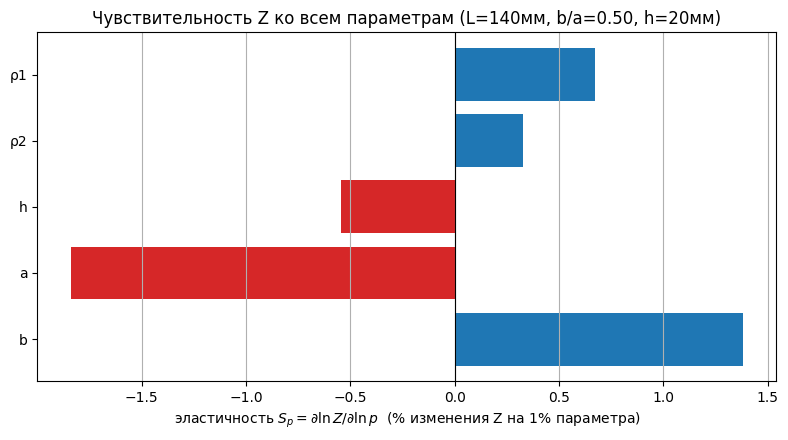

In [5]:
# @title Таблица и диаграмма чувствительности ко всем параметрам
a, b = ab_of(L_OP, BETA_OP)
Z = Z_model(RHO1, RHO2_OP, H_OP, a, b)

# (имя, значение параметра, производная, краткий смысл)
rows = [
 ('ρ1', RHO1,    dZ_drho1(RHO1,RHO2_OP,H_OP,a,b), 'сопр. мягких тканей'),
 ('ρ2', RHO2_OP, dZ_drho2(RHO1,RHO2_OP,H_OP,a,b), 'сопр. лёгкого = ДЫХАНИЕ (сигнал)'),
 ('h',  H_OP,    dZ_dh   (RHO1,RHO2_OP,H_OP,a,b), 'толщина жира = ПОМЕХА'),
 ('a',  a,       dZ_da   (RHO1,RHO2_OP,H_OP,a,b), 'токовая полубаза (геометрия)'),
 ('b',  b,       dZ_db   (RHO1,RHO2_OP,H_OP,a,b), 'потенц. полубаза (геометрия)'),
]

print('параметр |   ∂Z/∂p      | эластичность S_p | трактовка: +1%% параметра -> ... %% Z')
print('-'*92)
names, S = [], []
for nm, p, dZ, meaning in rows:
    Sp = p/Z*dZ                          # эластичность
    names.append(nm); S.append(Sp)
    print('  %-3s    | %+.4e | %+8.3f       | %+6.2f%%   (%s)' % (nm, dZ, Sp, Sp, meaning))

# диаграмма эластичностей
plt.figure(figsize=(8,4.5))
colors = ['C0' if s>=0 else 'C3' for s in S]
plt.barh(names[::-1], S[::-1], color=colors[::-1])
plt.axvline(0, color='k', lw=0.8)
plt.xlabel('эластичность $S_p=\\partial\\ln Z/\\partial\\ln p$  (% изменения Z на 1% параметра)')
plt.title('Чувствительность Z ко всем параметрам (L=%.0fмм, b/a=%.2f, h=%.0fмм)'%(L_OP*1000,BETA_OP,H_OP*1000))
plt.grid(True, axis='x'); plt.tight_layout(); plt.show()

### §2.1. Как читать результат

- **ρ₁ и ρ₂** — физика среды. Их эластичности в сумме дают 1 ($S_{\rho_1}+S_{\rho_2}=1$). В рабочей точке $S_{\rho_1}\approx0.67$, $S_{\rho_2}\approx0.33$ — то есть **мягкие ткани влияют на Z сильнее, чем лёгкое**: дыхательный сигнал ($\rho_2$) — лишь треть отклика. Это и есть корень проблемы: полезный сигнал слабее фона.
- **h** — отрицательная эластичность ($\approx-0.54$): толще жир ⟹ меньше Z. По модулю **сравнима с $S_{\rho_1}$ и больше $S_{\rho_2}$** — поэтому неопределённость толщины так опасна (§3).
- **a, b** — самые большие по модулю эластичности ($S_a\approx-1.8$, $S_b\approx+1.4$): Z очень чувствителен к **точности установки электродов**. Сдвиг электрода на 1 % уже меняет Z на 1–2 %. Вывод: позиционирование решётки должно быть точным (или учитываться в модели).

## §3. Откуда «10 % ошибки h → 17 % ошибки ρ₂». FoM (сигнал/помеха)

**Постановка обратной задачи.** Мы измеряем $Z$, считаем $\rho_1$ и $h$ известными и решаем уравнение модели относительно $\rho_2$. Если толщина $h$ задана с ошибкой, восстановленное $\rho_2$ смещается. На сколько?

Измеренное $Z$ фиксировано. Значит при сдвиге $h$ решатель подбирает такое $\rho_2$, чтобы модель по-прежнему давала это $Z$. Дифференцируем $Z(\rho_1,\rho_2,h)=\text{const}$:

$$\frac{\partial Z}{\partial \rho_2}\,d\rho_2+\frac{\partial Z}{\partial h}\,dh=0
\;\Longrightarrow\;
\boxed{\ \frac{\partial \ln \rho_2}{\partial \ln h}\bigg|_{Z}=-\frac{S_h}{S_{\rho_2}}\equiv K_h\ }$$

$K_h$ — **коэффициент усиления ошибки**: во сколько раз относительная ошибка в $h$ переходит в относительную ошибку $\rho_2$.

**FoM (figure of merit) = качество = $1/|K_h|$:**

$$\mathrm{FoM}=\frac{S_{\rho_2}}{|S_h|}=\frac{\text{«сигнал»}}{\text{«помеха»}}.$$

- **«сигнал»** $=S_{\rho_2}$ — насколько $Z$ реагирует на то, что мы **хотим** измерить (сопротивление лёгкого = дыхание);
- **«помеха»** $=|S_h|$ — насколько $Z$ реагирует на то, что мы знаем **неточно** (толщину жира).

$\mathrm{FoM}>1$ — сигнал сильнее помехи (ошибка $\rho_2$ меньше ошибки $h$); $\mathrm{FoM}<1$ — наоборот.

In [6]:
# @title Усиление ошибки в рабочей точке — с явными условиями
def Sr2_Sh(rho1, rho2, h, a, b):
    Z = Z_model(rho1, rho2, h, a, b)
    return rho2/Z*dZ_drho2(rho1,rho2,h,a,b), h/Z*dZ_dh(rho1,rho2,h,a,b)

def K_h(rho1, rho2, h, a, b):   # усиление ошибки  d ln rho2 / d ln h
    Sr2, Sh = Sr2_Sh(rho1, rho2, h, a, b)
    return -Sh/Sr2

a, b = ab_of(L_OP, BETA_OP)
Sr2, Sh = Sr2_Sh(RHO1, RHO2_OP, H_OP, a, b)
kh  = -Sh/Sr2
fom = Sr2/abs(Sh)
print('УСЛОВИЯ (рабочая точка): L=%.0f мм, b/a=%.2f, h=%.0f мм, rho1=%.1f, rho2=%.1f'
      % (L_OP*1000, BETA_OP, H_OP*1000, RHO1, RHO2_OP))
print('-'*64)
print('  сигнал  S_rho2 = %+.3f' % Sr2)
print('  помеха  S_h    = %+.3f' % Sh)
print('  FoM = S_rho2/|S_h| = %.3f' % fom)
print('  усиление ошибки K_h = -S_h/S_rho2 = %.2f' % kh)
print('  =>  10%% ошибки в h  ->  %.0f%% ошибки в rho2' % (10*abs(kh)))
print('  =>   5%% ошибки в h  ->  %.0f%% ошибки в rho2' % (5*abs(kh)))
print('\nИменно отсюда «10%% -> 17%%»: это значение K_h ИМЕННО в этой точке и зависит от геометрии (см. ниже).')

УСЛОВИЯ (рабочая точка): L=140 мм, b/a=0.50, h=20 мм, rho1=5.0, rho2=20.0
----------------------------------------------------------------
  сигнал  S_rho2 = +0.327
  помеха  S_h    = -0.543
  FoM = S_rho2/|S_h| = 0.602
  усиление ошибки K_h = -S_h/S_rho2 = 1.66
  =>  10% ошибки в h  ->  17% ошибки в rho2
  =>   5% ошибки в h  ->  8% ошибки в rho2

Именно отсюда «10%% -> 17%%»: это значение K_h ИМЕННО в этой точке и зависит от геометрии (см. ниже).


### §3.1. С чем связано усиление ошибки: размер L, отношение b/a или толщина h?

Покажем $K_h$ отдельно как функцию каждого фактора (остальные фиксированы в рабочей точке).

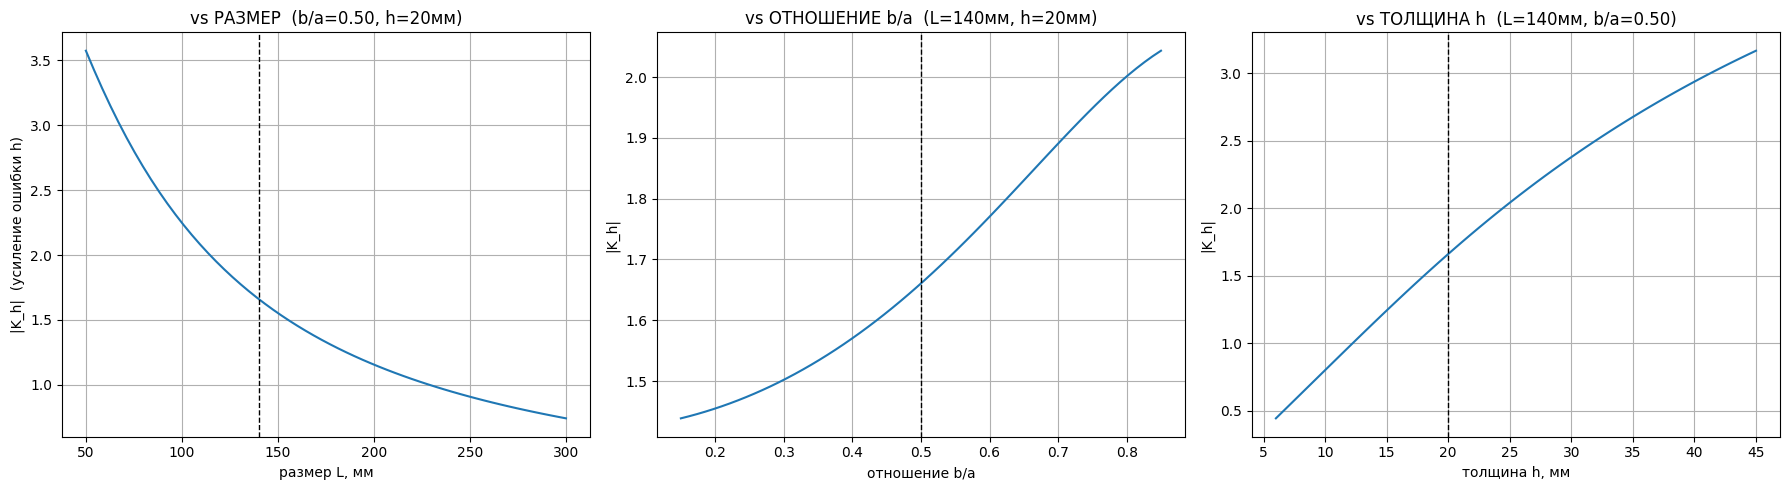

Размах |K_h|:  по L: 0.74..3.58 | по b/a: 1.44..2.04 | по h: 0.44..3.17


In [7]:
# @title K_h как функция L, b/a и h — три графика
Ls   = np.linspace(0.05, 0.30, 60)
betas= np.linspace(0.15, 0.85, 60)
hs1  = np.linspace(0.006, 0.045, 60)
a_fix = L_OP/2

Kh_L    = np.array([K_h(RHO1,RHO2_OP,H_OP,*ab_of(L,BETA_OP)) for L in Ls])
Kh_beta = np.array([K_h(RHO1,RHO2_OP,H_OP, a_fix, be*a_fix) for be in betas])
Kh_h    = np.array([K_h(RHO1,RHO2_OP,h,   *ab_of(L_OP,BETA_OP)) for h in hs1])

fig, ax = plt.subplots(1, 3, figsize=(18,5))
ax[0].plot(Ls*1000, np.abs(Kh_L)); ax[0].axvline(L_OP*1000, color='k', ls='--', lw=1)
ax[0].set_xlabel('размер L, мм'); ax[0].set_ylabel('|K_h|  (усиление ошибки h)')
ax[0].set_title('vs РАЗМЕР  (b/a=%.2f, h=%.0fмм)'%(BETA_OP,H_OP*1000)); ax[0].grid(True)

ax[1].plot(betas, np.abs(Kh_beta)); ax[1].axvline(BETA_OP, color='k', ls='--', lw=1)
ax[1].set_xlabel('отношение b/a'); ax[1].set_ylabel('|K_h|')
ax[1].set_title('vs ОТНОШЕНИЕ b/a  (L=%.0fмм, h=%.0fмм)'%(L_OP*1000,H_OP*1000)); ax[1].grid(True)

ax[2].plot(hs1*1000, np.abs(Kh_h)); ax[2].axvline(H_OP*1000, color='k', ls='--', lw=1)
ax[2].set_xlabel('толщина h, мм'); ax[2].set_ylabel('|K_h|')
ax[2].set_title('vs ТОЛЩИНА h  (L=%.0fмм, b/a=%.2f)'%(L_OP*1000,BETA_OP)); ax[2].grid(True)
plt.tight_layout(); plt.show()

print('Размах |K_h|:  по L: %.2f..%.2f | по b/a: %.2f..%.2f | по h: %.2f..%.2f'
      % (np.abs(Kh_L).min(),np.abs(Kh_L).max(),
         np.abs(Kh_beta).min(),np.abs(Kh_beta).max(),
         np.abs(Kh_h).min(),np.abs(Kh_h).max()))

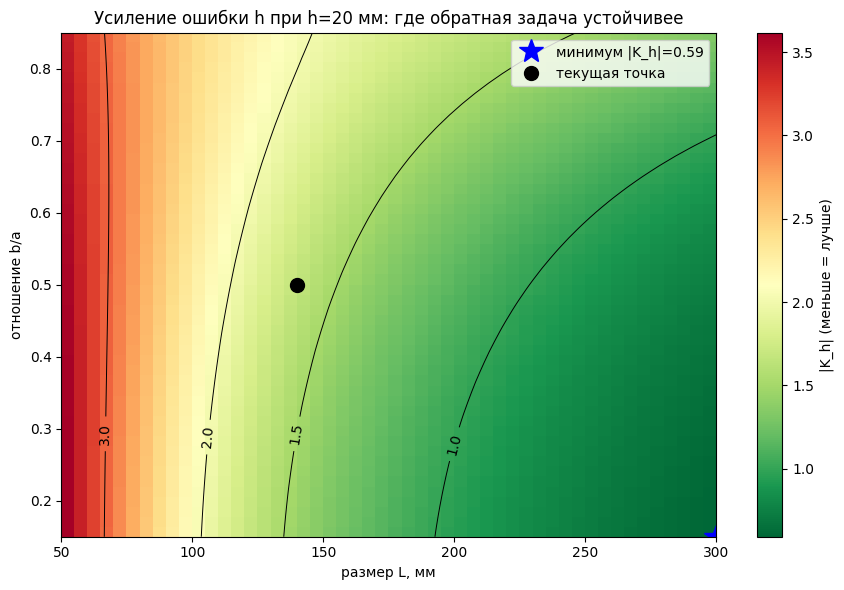

Лучшая комбинация при h=20мм: L=300 мм, b/a=0.15 -> |K_h|=0.59


In [8]:
# @title Карта |K_h|(L, b/a) при фиксированной толщине — лучшая комбинация
Lg   = np.linspace(0.05, 0.30, 50)
bg   = np.linspace(0.15, 0.85, 50)
LG, BG = np.meshgrid(Lg, bg)
KhMap = np.zeros_like(LG)
for ii in range(LG.shape[0]):
    for jj in range(LG.shape[1]):
        a = LG[ii,jj]/2
        KhMap[ii,jj] = abs(K_h(RHO1, RHO2_OP, H_OP, a, BG[ii,jj]*a))

plt.figure(figsize=(9,6))
im = plt.imshow(KhMap, origin='lower', aspect='auto',
                extent=[Lg[0]*1000, Lg[-1]*1000, bg[0], bg[-1]], cmap='RdYlGn_r',
                vmin=KhMap.min(), vmax=min(KhMap.max(), 4))
plt.colorbar(im, label='|K_h| (меньше = лучше)')
cs = plt.contour(LG*1000, BG, KhMap, levels=[0.5,1.0,1.5,2.0,3.0], colors='k', linewidths=0.7)
plt.clabel(cs, fmt='%.1f')
i0,j0 = np.unravel_index(np.argmin(KhMap), KhMap.shape)
plt.plot(Lg[j0]*1000, bg[i0], 'b*', ms=18, label='минимум |K_h|=%.2f'%KhMap.min())
plt.plot(L_OP*1000, BETA_OP, 'ko', ms=10, label='текущая точка')
plt.xlabel('размер L, мм'); plt.ylabel('отношение b/a')
plt.title('Усиление ошибки h при h=%.0f мм: где обратная задача устойчивее'%(H_OP*1000))
plt.legend(); plt.tight_layout(); plt.show()
print('Лучшая комбинация при h=%.0fмм: L=%.0f мм, b/a=%.2f -> |K_h|=%.2f'
      % (H_OP*1000, Lg[j0]*1000, bg[i0], KhMap.min()))

### §3.2. Выводы по усилению ошибки

- **Сильнее всего — от размера L.** Увеличение базы резко снижает $|K_h|$ (крупная решётка глубже «видит» лёгкое ⟹ дыхательный сигнал $S_{\rho_2}$ растёт ⟹ влияние неопределённости $h$ относительно слабеет). Это **главный рычаг** борьбы с неопределённостью жирового слоя.
- **Слабее — от отношения b/a.** Меньшее $b/a$ немного улучшает $|K_h|$, но эффект вторичен по сравнению с размером.
- **Толщина h — это сама помеха, а не рычаг.** Чем толще кожно-жировой слой, тем больше $|K_h|$: у «полных» пациентов та же относительная неопределённость $h$ сильнее портит $\rho_2$. Поэтому для них особенно важны крупные базы и/или **независимое измерение $h$** (УЗИ/МРТ).
- **Лучшая геометрия:** максимально возможный $L$ при умеренно малом $b/a$ (см. синюю звезду на карте).

## §4. Задача — сигнал дыхания $Z(\rho_2)$ по (L, h)

Карты эластичности к дыханию $S_{\rho_2}(L,h)$ и абсолютного размаха $\Delta Z_{\text{дых}}=Z(\rho_2^{вд})-Z(\rho_2^{выд})$.
$S_{\rho_2}$ — это «сигнал» из §3; видно, как он растёт с базой и падает с толщиной.

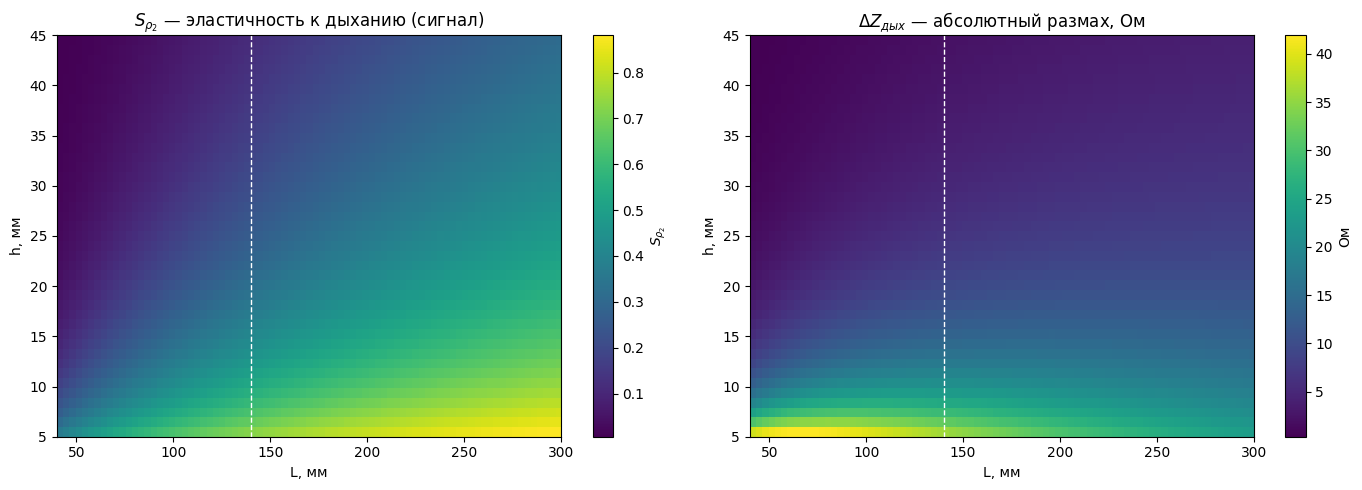

Белый пунктир — текущая макс. база 140 мм. Сигнал растёт вправо (база) и вниз (тоньше жир).


In [9]:
# @title Карты сигнала дыхания
Ls = np.linspace(L_MIN, L_MAX, NL)
hs = np.linspace(H_MIN, H_MAX, NH)
LL, HH = np.meshgrid(Ls, hs)
Sr2_map, dZ_map = np.zeros_like(LL), np.zeros_like(LL)
for ii in range(LL.shape[0]):
    for jj in range(LL.shape[1]):
        a, b = ab_of(LL[ii,jj], BETA_OP)
        Sr2_map[ii,jj] = Sr2_Sh(RHO1, RHO2_OP, HH[ii,jj], a, b)[0]
        dZ_map[ii,jj]  = (Z_model(RHO1,RHO2_IN,HH[ii,jj],a,b)
                          - Z_model(RHO1,RHO2_EX,HH[ii,jj],a,b))

fig, ax = plt.subplots(1, 2, figsize=(14,5))
ext = [Ls[0]*1000, Ls[-1]*1000, hs[0]*1000, hs[-1]*1000]
for k,(M,ttl,lab) in enumerate([(Sr2_map,'$S_{\\rho_2}$ — эластичность к дыханию (сигнал)','$S_{\\rho_2}$'),
                                 (dZ_map,'$\\Delta Z_{дых}$ — абсолютный размах, Ом','Ом')]):
    im = ax[k].imshow(M, origin='lower', aspect='auto', extent=ext, cmap='viridis')
    ax[k].set_title(ttl); ax[k].set_xlabel('L, мм'); ax[k].set_ylabel('h, мм')
    ax[k].axvline(140, color='w', ls='--', lw=1)
    fig.colorbar(im, ax=ax[k], label=lab)
plt.tight_layout(); plt.show()
print('Белый пунктир — текущая макс. база 140 мм. Сигнал растёт вправо (база) и вниз (тоньше жир).')

## §5. Минимальный размер решётки $L_{\min}(h)$

Наименьшая база, при которой дыхание ещё информативно. Три критерия:
- **I (по шуму):** $\Delta Z_{\text{дых}}\ge c\,\sigma_Z$;
- **II (геометрический):** доля проникновения $F=\dfrac{\rho_a-\rho_1}{\rho_2-\rho_1}\ge F^\ast$;
- **III (идентифицируемость):** $S_{\rho_2}\ge S^\ast$ и $\mathrm{FoM}\ge\mathrm{FoM}^\ast$ (контроль усиления ошибки h).

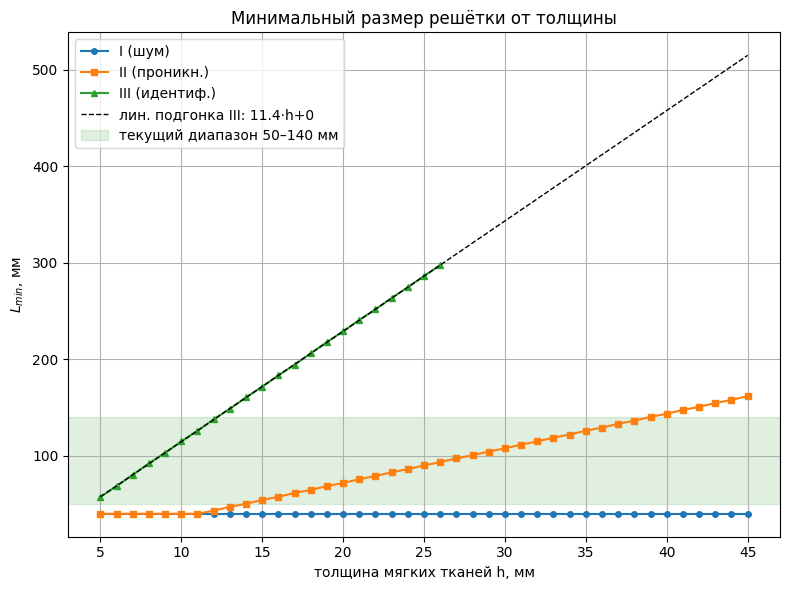

Наклон Lmin(III) ≈ 11.4 -> подтверждает линейный закон Lmin ∝ h.
Где кривая выходит выше зелёной зоны — текущих баз не хватает (толстый жировой слой).


In [10]:
# @title Lmin(h) по трём критериям
F_STAR, S_STAR, FOM_STAR = 0.10, 0.30, 1.0
Lscan = np.linspace(L_MIN, L_MAX, 400)

def Lmin_at(h):
    out = {}
    dZ = np.array([Z_model(RHO1,RHO2_IN,h,*ab_of(L)) - Z_model(RHO1,RHO2_EX,h,*ab_of(L)) for L in Lscan])
    out['I (шум)'] = next((L for L,v in zip(Lscan,dZ) if v >= C_SNR*SIGMA_Z), np.nan)
    F  = np.array([(rho_apparent(Z_model(RHO1,RHO2_OP,h,*ab_of(L)),*ab_of(L))-RHO1)/(RHO2_OP-RHO1) for L in Lscan])
    out['II (проникн.)'] = next((L for L,v in zip(Lscan,F) if v >= F_STAR), np.nan)
    SF = np.array([Sr2_Sh(RHO1,RHO2_OP,h,*ab_of(L)) for L in Lscan])
    Sr = SF[:,0]; fom = SF[:,0]/np.abs(SF[:,1])
    out['III (идентиф.)'] = next((L for L,s,f in zip(Lscan,Sr,fom) if s>=S_STAR and f>=FOM_STAR), np.nan)
    return out

curves = {c: [] for c in ['I (шум)','II (проникн.)','III (идентиф.)']}
for h in hs:
    r = Lmin_at(h)
    for c in curves: curves[c].append(r[c])

plt.figure(figsize=(8,6))
for c,st in zip(curves, ['o-','s-','^-']):
    plt.plot(hs*1000, np.array(curves[c])*1000, st, ms=4, label=c)
yIII = np.array(curves['III (идентиф.)'])*1000; m = np.isfinite(yIII)
p = np.polyfit(hs[m]*1000, yIII[m], 1)
plt.plot(hs*1000, np.polyval(p, hs*1000), 'k--', lw=1, label='лин. подгонка III: %.1f·h+%.0f'%(p[0],p[1]))
plt.axhspan(50,140, color='green', alpha=0.12, label='текущий диапазон 50–140 мм')
plt.xlabel('толщина мягких тканей h, мм'); plt.ylabel('$L_{min}$, мм')
plt.title('Минимальный размер решётки от толщины'); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
print('Наклон Lmin(III) ≈ %.1f -> подтверждает линейный закон Lmin ∝ h.' % p[0])
print('Где кривая выходит выше зелёной зоны — текущих баз не хватает (толстый жировой слой).')

## §6. Обоснование набора баз — матрица Фишера

Для набора баз $\{L_k\}$ строим якобиан по $\theta=(\rho_1,h,\rho_2)$, матрицу Фишера $\mathbf M=J^\top J/\sigma^2$ и ковариацию $\mathbf C=\mathbf M^{-1}$. Метрики качества набора:
- $\mathrm{std}(\hat\rho_2)=\sqrt{C_{\rho_2\rho_2}}$ — неопределённость лёгкого (меньше = лучше);
- $\mathrm{corr}(h,\rho_2)$ — вырождение «толщина↔лёгкое» (ближе к 0 = лучше);
- $\mathrm{cond}(\mathbf M)$ — общая обусловленность.

In [11]:
# @title Сравнение наборов баз
def fisher(L_set, rho1, h, rho2, sigma=SIGMA_Z, beta=BETA_OP):
    J = np.array([[dZ_drho1(rho1,rho2,h,*ab_of(L,beta)),
                   dZ_dh   (rho1,rho2,h,*ab_of(L,beta)),
                   dZ_drho2(rho1,rho2,h,*ab_of(L,beta))] for L in L_set])
    M = J.T @ J / sigma**2
    C = np.linalg.inv(M)
    return dict(std_rho2=np.sqrt(C[2,2]),
                corr=C[1,2]/np.sqrt(C[1,1]*C[2,2]),
                cond=np.linalg.cond(M))

designs = {
 'текущий 50–140 (шаг 10)':     np.arange(50,141,10)/1000,
 'расширенный 50–200 (шаг 15)': np.arange(50,201,15)/1000,
 'расширенный 50–300 (шаг 25)': np.arange(50,301,25)/1000,
 'только крупные 100–200':      np.arange(100,201,20)/1000,
}
print('%-30s | std(rho2) | corr(h,rho2) | cond(M)' % 'набор баз')
print('-'*78)
for name, Ls_ in designs.items():
    r = fisher(Ls_, RHO1, H_OP, RHO2_OP)
    print('%-30s |  %7.3f  |    %5.2f     | %.1e' % (name, r['std_rho2'], r['corr'], r['cond']))
print('\nВывод: расширение баз вверх снижает std(rho2) и корреляцию h↔rho2 (разрывает вырождение).')

набор баз                      | std(rho2) | corr(h,rho2) | cond(M)
------------------------------------------------------------------------------
текущий 50–140 (шаг 10)        |    0.078  |     0.97     | 3.9e+08
расширенный 50–200 (шаг 15)    |    0.037  |     0.94     | 8.2e+07
расширенный 50–300 (шаг 25)    |    0.021  |     0.89     | 2.1e+07
только крупные 100–200         |    0.108  |     0.96     | 4.0e+08

Вывод: расширение баз вверх снижает std(rho2) и корреляцию h↔rho2 (разрывает вырождение).


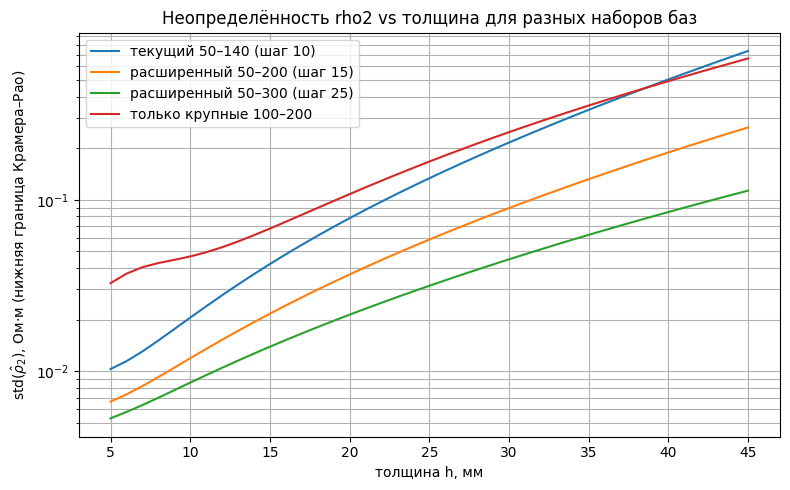

Для больших h текущий набор даёт резко худшую оценку — нужны крупные базы.


In [12]:
# @title Робастность набора по толщине h
plt.figure(figsize=(8,5))
for name, Ls_ in designs.items():
    std = [fisher(Ls_, RHO1, h, RHO2_OP)['std_rho2'] for h in hs]
    plt.plot(hs*1000, std, label=name)
plt.xlabel('толщина h, мм'); plt.ylabel('std($\\hat\\rho_2$), Ом·м (нижняя граница Крамера–Рао)')
plt.yscale('log'); plt.title('Неопределённость rho2 vs толщина для разных наборов баз')
plt.legend(); plt.grid(True, which='both'); plt.tight_layout(); plt.show()
print('Для больших h текущий набор даёт резко худшую оценку — нужны крупные базы.')

## §7. (опционально) Глобальная чувствительность — индексы Соболя

Локальные эластичности (§2) зависят от рабочей точки. Глобальный анализ Соболя оценивает вклад каждого параметра во **всём** диапазоне $(\rho_1,\rho_2,h)$. Требует пакета `SALib`.

C:\Users\ПАВЛУША\AppData\Local\Temp\ipykernel_1736\1890628829.py:9: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  X = saltelli.sample(problem, 256, calc_second_order=False)


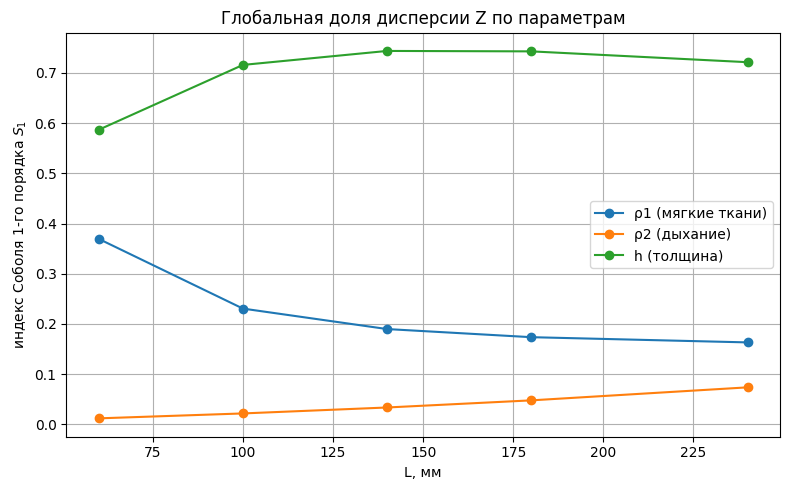

Доля дисперсии от ρ2 (дыхание) растёт с базой; h остаётся весомой помехой.


In [17]:
# @title Индексы Соболя по размеру L (если установлен SALib)
try:
    from SALib.sample import saltelli
    from SALib.analyze import sobol
    problem = {'num_vars':3, 'names':['rho1','rho2','h'],
               'bounds':[[3.0,7.0],[RHO2_EX,RHO2_IN],[H_MIN,H_MAX]]}
    L_list = np.array([0.06,0.10,0.14,0.18,0.24])
    S1 = {n:[] for n in problem['names']}
    X = saltelli.sample(problem, 256, calc_second_order=False)
    for L in L_list:
        a,b = ab_of(L)
        Y = np.array([Z_model(r1,r2,h,a,b) for r1,r2,h in X])
        Si = sobol.analyze(problem, Y, calc_second_order=False, print_to_console=False)
        for j,n in enumerate(problem['names']): S1[n].append(Si['S1'][j])
    plt.figure(figsize=(8,5))
    lab = {'rho1':'ρ1 (мягкие ткани)','rho2':'ρ2 (дыхание)','h':'h (толщина)'}
    for n in problem['names']:
        plt.plot(L_list*1000, S1[n], 'o-', label=lab[n])
    plt.xlabel('L, мм'); plt.ylabel('индекс Соболя 1-го порядка $S_1$')
    plt.title('Глобальная доля дисперсии Z по параметрам'); plt.legend(); plt.grid(True)
    plt.tight_layout(); plt.show()
    print('Доля дисперсии от ρ2 (дыхание) растёт с базой; h остаётся весомой помехой.')
except ImportError:
    print('SALib не установлен. Установите: pip install SALib  (или пропустите эту ячейку).')

## §8. Оптимизация геометрии решётки $(L,\beta)$ на калиброванных данными параметрах

Постановка из [`06_Перекрёстная_проверка_и_применимость.md`](06_Перекрёстная_проверка_и_применимость.md) §7. Свободных переменных две: размер $L$ и форма $\beta=b/a$ (так как $a=L/2$, $b=\beta a$). Целевая — c-оптимальность $\min\,\mathrm{std}(\hat\rho_2)=\sqrt{(\mathbf M^{-1})_{\rho_2\rho_2}}$ (матрица Фишера `fisher()` из §6).

Данные превращают априорный дизайн в расчёт: рабочая точка $(\rho_1,\rho_2,h)$ — из `09_Статическая_оценка_параметров.ipynb`; $\sigma_Z$ — из разброса плато; верхняя граница $L_{\max}$ — из КТ/МКЭ.

⚠ $\beta$ оптимизируется **только модельно** (все измерения при $\beta=0.5$); $\{L_k\}$ — проверяемо на данных. $L_{\max}$ здесь — заглушка, замените значением из КТ.

In [14]:
# @title §8.1 Рабочая точка из данных, ограничения, c-оптимальность
# рабочая точка <- params/static.json (09) + params/ct.json (10); ρ2 предпочтительно из КТ.
import os as _os, json as _json
def _ld(p):
    pth = _os.path.join("params", p)
    return _json.load(open(pth, encoding="utf-8")) if _os.path.exists(pth) else {}
_st, _ct = _ld("static.json"), _ld("ct.json")
if _st:
    OP = {"%s (h=%.0f)" % (n, _st[n]["h"]*1000):
          dict(rho1=_st[n]["rho1"], rho2=(_ct.get(n, {}).get("rho2_ct") or _st[n]["rho2_in"]), h=_st[n]["h"])
          for n in _st}
else:
    OP = {"Ник (h=15)": dict(rho1=4.73, rho2=17.7, h=0.015),
          "Георгий (h=40)": dict(rho1=13.2, rho2=20.0, h=0.040)}
SIGMA_DATA = 0.05          # шум Z, Ом — из разброса плато/остатков фита (замените)
L_MAX_MM   = 200.0         # верхняя граница плоскостности из КТ/МКЭ (заглушка)

def std_rho2(L_set_m, op, sigma=SIGMA_DATA, beta=BETA_OP):
    if len(L_set_m) < 3:        # для 3 параметров (ρ1,h,ρ2) нужно ≥3 базы
        return np.inf
    try:
        return fisher(np.asarray(L_set_m), op["rho1"], op["h"], op["rho2"], sigma, beta)["std_rho2"]
    except np.linalg.LinAlgError:
        return np.inf

cur = np.arange(50, 141, 10)/1000.0
print("c-оптимальность = min std(ρ2). L набора ∈ [40, %.0f мм]: мелкие базы закрепляют ρ1,\n"
      "крупные несут ρ2; верх ограничен плоскостностью Lmax из КТ (§8.3).\n" % L_MAX_MM)
for name, op in OP.items():
    print("  %-16s std(ρ2) текущего набора 50–140 = %.3f Ом·м" % (name, std_rho2(cur, op)))

c-оптимальность = min std(ρ2). L набора ∈ [40, 200 мм]: мелкие базы закрепляют ρ1,
крупные несут ρ2; верх ограничен плоскостностью Lmax из КТ (§8.3).

  Георгий (h=40)   std(ρ2) текущего набора 50–140 = 0.372 Ом·м
  Ник (h=15)       std(ρ2) текущего набора 50–140 = 0.096 Ом·м


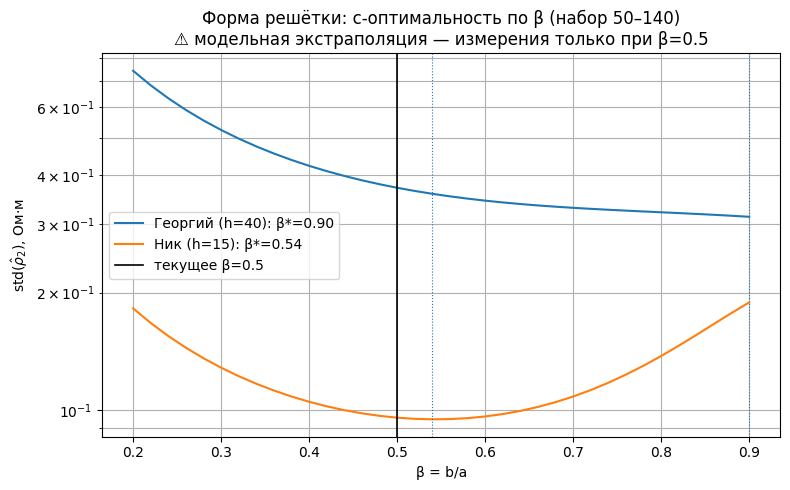

In [15]:
# @title §8.2 Оптимизация формы β = b/a (МОДЕЛЬНО)
betas = np.linspace(0.2, 0.9, 36)
plt.figure(figsize=(8, 5))
for name, op in OP.items():
    s = [std_rho2(cur, op, beta=bb) for bb in betas]
    b_star = betas[int(np.argmin(s))]
    plt.plot(betas, s, label="%s: β*=%.2f" % (name, b_star))
    plt.axvline(b_star, ls=":", lw=0.8)
plt.axvline(0.5, color="k", lw=1.2, label="текущее β=0.5")
plt.xlabel("β = b/a"); plt.ylabel("std($\\hat\\rho_2$), Ом·м"); plt.yscale("log")
plt.title("Форма решётки: c-оптимальность по β (набор 50–140)\n⚠ модельная экстраполяция — измерения только при β=0.5")
plt.legend(); plt.grid(True, which="both"); plt.tight_layout(); plt.show()

субъект          | std тек.50–140 | оптим. набор {L_k}, мм                 | std опт.
--------------------------------------------------------------------------------------------
Георгий (h=40)   |    0.372      | [40, 70, 80, 90, 100, 110, 120, 180, 190, 200] | 0.115
Ник (h=15)       |    0.096      | [40, 60, 70, 80, 90, 120, 170, 180, 190, 200] | 0.039


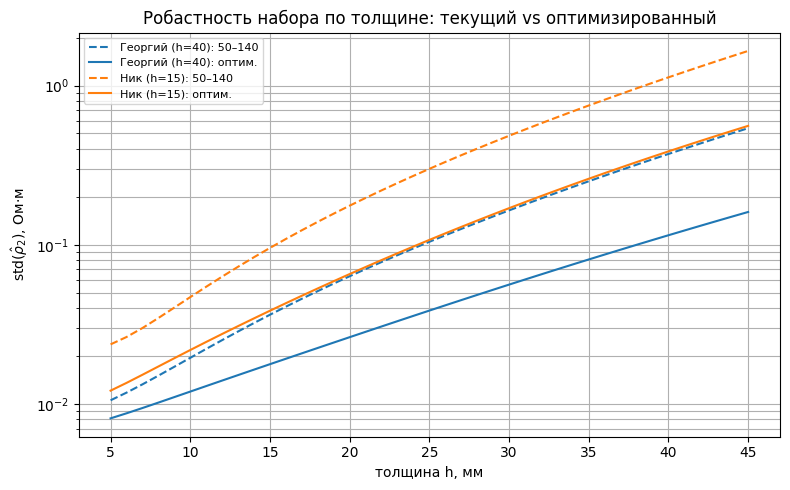

In [16]:
# @title §8.3 Оптимизация набора {L_k} под ограничениями + робастность по h
# Нижняя граница набора — физический минимум базы (НЕ Lmin): мелкие решётки нужны,
# чтобы закрепить ρ1,h и разорвать вырождение h<->ρ2 (§2, §8-9 дизайн-доку).
# Верхняя — Lmax(h) из КТ (плоскостность).
L_MIN_MM = 40.0
GRID = np.arange(L_MIN_MM, int(L_MAX_MM)+1, 10)/1000.0      # сетка возможных размеров, м
K = 10                                                       # число решёток в наборе

def greedy_design(op, K):
    cand = list(GRID)
    chosen = [cand[0], cand[len(cand)//2], cand[-1]]          # стартовый спред для невырожденной M
    while len(chosen) < min(K, len(cand)):
        rest = [L for L in cand if L not in chosen]
        L_best = min(rest, key=lambda L: std_rho2(np.array(sorted(chosen+[L])), op))
        chosen.append(L_best)
    return np.array(sorted(chosen))

print("%-16s | std тек.50–140 | оптим. набор {L_k}, мм                 | std опт." % "субъект")
print("-"*92)
for name, op in OP.items():
    opt = greedy_design(op, K)
    print("%-16s |    %.3f      | %-38s | %.3f"
          % (name, std_rho2(cur, op), str([int(x*1000) for x in opt]), std_rho2(opt, op)))

# робастность: средняя std(ρ2) по диапазону h для текущего и оптимизированного наборов
plt.figure(figsize=(8, 5))
for name, op in OP.items():
    opt = greedy_design(op, K)
    cur_h = [std_rho2(cur, dict(op, h=h)) for h in hs]
    opt_h = [std_rho2(opt, dict(op, h=h)) for h in hs]
    ln, = plt.plot(hs*1000, cur_h, "--", label="%s: 50–140" % name)
    plt.plot(hs*1000, opt_h, "-", color=ln.get_color(), label="%s: оптим." % name)
plt.xlabel("толщина h, мм"); plt.ylabel("std($\\hat\\rho_2$), Ом·м"); plt.yscale("log")
plt.title("Робастность набора по толщине: текущий vs оптимизированный")
plt.legend(fontsize=8); plt.grid(True, which="both"); plt.tight_layout(); plt.show()

### §8.4. Выводы

- При фиксированном $\beta=0.5$ расширение набора вверх (к $L_{\max}$ из КТ) снижает $\mathrm{std}(\hat\rho_2)$, особенно для толстых тканей — крупные базы несут $\rho_2$ (ср. §6).
- Оптимум по $\beta$ — **модельное предсказание** для будущих решёток; подтверждается только измерениями при других $\beta$.
- Ключевое ограничение — $L_{\max}(h,\text{анатомия})$: без него оптимизатор бесконтрольно растит $L$. Замените заглушку `L_MAX_MM` границей плоскостности из КТ/МКЭ (§2.5, §3.3 документа перекрёстной проверки).
- Рабочую точку $(\rho_1,\rho_2,h)$ и $\sigma_Z$ обновляйте из `09_Статическая_оценка_параметров.ipynb`.